In [1]:
import sys
from pathlib import Path

# 本 notebook 所在目录：.../CACE-SOG/fit-4hdnnp-NaCl
TASK_DIR = Path("/work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-4hdnnp-NaCl-initial").resolve()
ROOT_DIR = TASK_DIR.parent  # .../CACE-SOG-Qeq（含 cace 包）
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from ase.io import read
import cace
import torch
import numpy as np
from torch import nn
from cace.tools.scatter import scatter_sum
from cace.tools import torch_geometric
from cace.data.extxyz_charge import read_extxyz_with_charge

# 兼容旧 checkpoint：该类训练时定义在脚本 __main__，加载时必须先在当前 __main__ 提供同名类
class SystemChargeFromAtomicCharges(nn.Module):
    """将每结构总电荷写入 data['system_charge']。"""
    def __init__(self, charges_key: str = "charge", output_key: str = "system_charge"):
        super().__init__()
        self.charges_key = charges_key
        self.output_key = output_key
        self.model_outputs = [output_key]

    def forward(self, data: dict, **kwargs):
        if self.charges_key not in data or data[self.charges_key] is None:
            if data.get("batch", None) is None:
                num_graphs = 1
            else:
                num_graphs = int(data["batch"].max().item()) + 1 if data["batch"].numel() > 0 else 1
            data[self.output_key] = torch.zeros((num_graphs,), device=data["positions"].device, dtype=data["positions"].dtype)
            return data

        q = data[self.charges_key]
        if q.dim() > 1:
            q = q.view(-1)
        if data.get("batch", None) is None:
            system_q = q.sum().view(1)
        else:
            system_q = scatter_sum(q, data["batch"], dim=0)
        data[self.output_key] = system_q
        return data

MODEL_PATH = TASK_DIR / "best_model.pth"
DATA_PATH = TASK_DIR / "NaCl.xyz"
print("ROOT_DIR:", ROOT_DIR)
print("model:", MODEL_PATH)
print("data:", DATA_PATH)

model = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
model.eval()

# 保留 ASE 数据（仅用于某些可视化/兼容）
data = read(str(DATA_PATH), ":")

# 关键修正：评估必须走带 charge 的数据管线，避免 EvaluateTask(list[Atoms]) 丢失 charge
z_map = {"Na": 11, "Cl": 17}
atomic_energies = {11: -4417.07609365649, 17: -12516.880649933015}
cutoff = float(model.models[0].representation.cutoff) if hasattr(model, "models") else float(model.representation.cutoff)

data_with_charge = read_extxyz_with_charge(
    path=str(DATA_PATH),
    cutoff=cutoff,
    atomic_energies=atomic_energies,
    z_map=z_map,
)
print("num structures (with charge):", len(data_with_charge))


def evaluate_model_on_atomicdata(model, dataset, batch_size=8, device="cpu"):
    loader = torch_geometric.dataloader.DataLoader(
        dataset, batch_size=batch_size, shuffle=False, drop_last=False
    )
    energies, forces = [], []
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)
        if "CACE_energy" not in out or "CACE_forces" not in out:
            raise KeyError(f"missing keys in model output: {list(out.keys())}")
        energies.append(out["CACE_energy"].detach().cpu().numpy().reshape(-1))
        forces.append(out["CACE_forces"].detach().cpu().numpy())
    return {
        "energy": np.concatenate(energies, axis=0),
        "forces": np.concatenate(forces, axis=0),
    }


ROOT_DIR: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq
model: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-4hdnnp-NaCl-initial/best_model.pth
data: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-4hdnnp-NaCl-initial/NaCl.xyz
num structures (with charge): 5000


In [2]:
import numpy as np

def load_ref_energy_forces_from_extxyz(path, atomic_energies, z_map):
    energies, atom_nums, forces_blocks = [], [], []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            header = f.readline().strip()
            energy = None
            if "energy=" in header:
                try:
                    e_str = header.split("energy=")[1].split()[0]
                    energy = float(e_str)
                except Exception:
                    energy = None
            species, fl = [], []
            for _ in range(nat):
                parts = f.readline().split()
                species.append(parts[0])
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                fl.append(vals[3:6])
            Z = [z_map[s] for s in species]
            if energy is not None and atomic_energies is not None:
                energy -= sum(atomic_energies.get(int(z), 0.0) for z in Z)
            if energy is None:
                raise ValueError("no energy= in frame header")
            energies.append(energy)
            atom_nums.append(nat)
            forces_blocks.append(np.asarray(fl, dtype=np.float64))
    ref_energy = np.asarray(energies, dtype=np.float64)
    atom_num = np.asarray(atom_nums, dtype=np.float64)
    ref_force = np.concatenate(forces_blocks, axis=0)
    return ref_energy, atom_num, ref_force

In [3]:
# 与 cell0 中保持一致
z_map = {"Na": 11, "Cl": 17}
atomic_energies = {11: -4417.07609365649, 17: -12516.880649933015}
ref_energy, atom_num, ref_force = load_ref_energy_forces_from_extxyz(
    str(DATA_PATH), atomic_energies, z_map
)

In [4]:
pre = evaluate_model_on_atomicdata(model, data_with_charge, batch_size=8, device="cpu")
pre["energy"]

array([ 0.15819168,  0.02521229,  0.0734129 , ...,  0.08174133,
       -0.02929592, -0.16609764], dtype=float32)

In [5]:
ref_energy

array([ 0.15517016,  0.02694292,  0.07818196, ...,  0.07356963,
       -0.02910438, -0.16642664])

In [6]:
np.sqrt(np.mean(((ref_energy-pre['energy'])/atom_num)**2))

0.00017198563811438825

In [ ]:
# ref_force 已在 extxyz 文本解析时得到（避免依赖 ASE arrays['forces']）

In [7]:
ref_force

array([[ 0.39800816, -0.68243252, -0.04029912],
       [ 0.10724183,  0.69007668,  0.03912941],
       [-0.27604536, -0.07410034,  0.02231662],
       ...,
       [-0.25685662, -0.2638167 , -0.01166   ],
       [ 0.09980141,  0.19741163,  0.00446011],
       [ 0.20005152, -0.12714504,  0.00384018]])

In [ ]:
# ref_force shape: (N_total_atoms, 3)

In [8]:
np.sqrt(np.mean((ref_force-pre['forces'])**2))

0.007922200347955852

q key used: q_eq
q MAE : 1.8812404808013883
q RMSE: 1.9946922135445162
q R^2 : -25.12718464450078
q_ref range : -0.50890273 0.75680671
q_pred range: -3.1595563888549805 4.956697463989258
norm_factor: 0.10538150852788286
q MAE (scaled): 0.15900433002508113
q RMSE(scaled): 0.18500742447930105


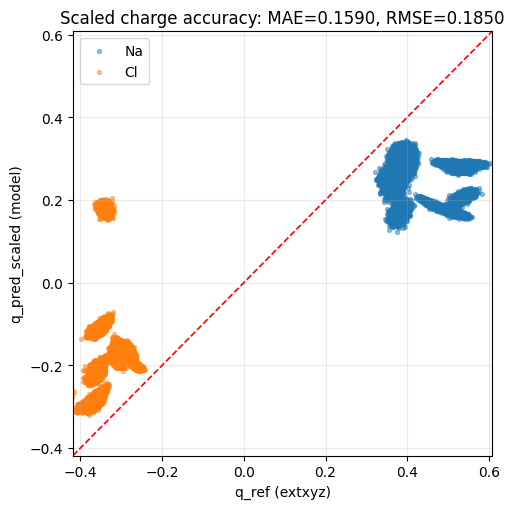

In [15]:
# 电荷准确度：q_ref vs q_pred（散点图 + MAE/RMSE/R^2）
import numpy as np
import matplotlib.pyplot as plt


def load_ref_charge_from_extxyz(path):
    q_blocks = []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            _ = f.readline()  # header
            q_now = []
            for _ in range(nat):
                parts = f.readline().split()
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                q_now.append(vals[6])
            q_blocks.append(np.asarray(q_now, dtype=np.float64))
    return np.concatenate(q_blocks, axis=0)


def predict_q_from_model(model, atomicdata_list, device="cpu"):
    model.eval()
    loader = torch_geometric.dataloader.DataLoader(
        atomicdata_list, batch_size=8, shuffle=False, drop_last=False
    )

    q_all = []
    q_key_used = None
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)

        if "q_eq" in out:
            q_key = "q_eq"
        elif "q" in out:
            q_key = "q"
        else:
            raise KeyError(f"model output keys have no 'q_eq' or 'q': {list(out.keys())}")

        q_key_used = q_key
        q_all.append(out[q_key].detach().cpu().numpy().reshape(-1))

    return np.concatenate(q_all, axis=0), q_key_used


q_ref = load_ref_charge_from_extxyz(str(DATA_PATH))
q_pred, q_key_used = predict_q_from_model(model, data_with_charge, device="cpu")
print("q key used:", q_key_used)

assert q_ref.shape == q_pred.shape, f"shape mismatch: q_ref={q_ref.shape}, q_pred={q_pred.shape}"

mae = float(np.mean(np.abs(q_ref - q_pred)))
rmse = float(np.sqrt(np.mean((q_ref - q_pred) ** 2)))
ss_res = float(np.sum((q_ref - q_pred) ** 2))
ss_tot = float(np.sum((q_ref - np.mean(q_ref)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

print("q MAE :", mae)
print("q RMSE:", rmse)
print("q R^2 :", r2)
print("q_ref range :", float(q_ref.min()), float(q_ref.max()))
print("q_pred range:", float(q_pred.min()), float(q_pred.max()))

# 对 Qeq 模型，q 常是归一化表征；给出按 norm_factor 还原后的误差
charge_eq_mod = None
for m in model.modules():
    if m.__class__.__name__ == "ChargeEq":
        charge_eq_mod = m
        break
if charge_eq_mod is not None and hasattr(charge_eq_mod, "normalization_factor"):
    nf = float(charge_eq_mod.normalization_factor)
    q_pred_scaled = q_pred * nf
    mae_scaled = float(np.mean(np.abs(q_ref - q_pred_scaled)))
    rmse_scaled = float(np.sqrt(np.mean((q_ref - q_pred_scaled) ** 2)))
    print("norm_factor:", nf)
    print("q MAE (scaled):", mae_scaled)
    print("q RMSE(scaled):", rmse_scaled)

# 只绘制 scaled q_pred，并按元素（Na/Cl）着色
# 元素序列与 q_ref / q_pred 顺序保持一致（按结构、按原子顺序展开）
elem_Z = np.concatenate([
    d.atomic_numbers.detach().cpu().numpy().reshape(-1)
    if hasattr(d.atomic_numbers, "detach")
    else np.asarray(d.atomic_numbers).reshape(-1)
    for d in data_with_charge
]).astype(int)

if charge_eq_mod is None or not hasattr(charge_eq_mod, "normalization_factor"):
    raise ValueError("ChargeEq normalization_factor not found; cannot draw scaled q_pred only.")

q_pred_scaled = q_pred * float(charge_eq_mod.normalization_factor)
assert elem_Z.shape[0] == q_ref.shape[0] == q_pred_scaled.shape[0], (
    f"shape mismatch: elem_Z={elem_Z.shape}, q_ref={q_ref.shape}, q_pred_scaled={q_pred_scaled.shape}"
)

mask_na = elem_Z == 11
mask_cl = elem_Z == 17

plt.figure(figsize=(5.2, 5.2))
plt.scatter(q_ref[mask_na], q_pred_scaled[mask_na], s=8, alpha=0.45, c="#1f77b4", label="Na")
plt.scatter(q_ref[mask_cl], q_pred_scaled[mask_cl], s=8, alpha=0.45, c="#ff7f0e", label="Cl")

# 轴范围仅按 scaled q_pred 的数值设置，留极小边界
y_min = float(q_pred_scaled.min())
y_max = float(q_pred_scaled.max())
pad = 0.10 * max(1e-8, (y_max - y_min))
lo = y_min - pad
hi = y_max + pad

plt.plot([lo, hi], [lo, hi], "r--", lw=1.2)
plt.xlim(lo, hi)
plt.ylim(lo, hi)

plt.xlabel("q_ref (extxyz)")
plt.ylabel("q_pred_scaled (model)")
plt.title(f"Scaled charge accuracy: MAE={mae_scaled:.4f}, RMSE={rmse_scaled:.4f}")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()